In [23]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

In [2]:
# Load Dataset
df = pd.read_csv("supermarket_sales_forecasting_dirty_dataset.csv")

In [3]:
df.head()

,Date,Store,Product_Category,Units_Sold,Unit_Price,Promotion,Inventory_Level,Sales_Revenue
0,2025-01-01,Store_A,Snacks,31.0,29.99,0,365.0,929.69
1,2025-01-02,Store_A,Household,86.0,39.60,0,737.0,3405.60
2,2025-01-03,Store_C,Groceries,84.0,47.51,0,845.0,3990.84
3,2025-01-04,Store_B,Snacks,180.0,43.23,1,642.0,8948.61
4,2025-01-05,Store_B,Snacks,187.0,16.13,0,163.0,3016.31


In [4]:
df.shape

(310, 8)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 310 entries, 0 to 309
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Date              310 non-null    object 
 1   Store             310 non-null    object 
 2   Product_Category  310 non-null    object 
 3   Units_Sold        301 non-null    object 
 4   Unit_Price        297 non-null    float64
 5   Promotion         310 non-null    int64  
 6   Inventory_Level   301 non-null    float64
 7   Sales_Revenue     310 non-null    float64
dtypes: float64(3), int64(1), object(4)
memory usage: 19.5+ KB


In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Unit_Price,297.0,26.830943,12.594726,5.21,15.680,26.330,38.19,49.55
Promotion,310.0,0.280645,0.450041,0.00,0.000,0.000,1.00,1.00
Inventory_Level,301.0,514.202658,277.363135,51.00,276.000,508.000,749.00,996.00
Sales_Revenue,310.0,3863.305484,2640.477224,249.48,1854.175,3288.385,5504.67,11741.58


In [7]:
df.dtypes

Date                 object
Store                object
Product_Category     object
Units_Sold           object
Unit_Price          float64
Promotion             int64
Inventory_Level     float64
Sales_Revenue       float64
dtype: object

In [8]:
df.isnull().sum()

Date                 0
Store                0
Product_Category     0
Units_Sold           9
Unit_Price          13
Promotion            0
Inventory_Level      9
Sales_Revenue        0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(10)

## Phase 1 Summary

We started by examining the dataset using df.shape, df.info(), and df.describe().T. These functions helped us understand the dataset dimensions, data types, and statistical information. We also used df.isnull().sum() and df.duplicated().sum() to identify missing values and duplicate records. This phase helped us detect data quality issues before cleaning.

In [10]:
print("Duplicates Before:", df.duplicated().sum())

df = df.drop_duplicates()

print("Duplicates After:", df.duplicated().sum())

Duplicates Before: 10
Duplicates After: 0


In [11]:
df["Units_Sold"] = pd.to_numeric(df["Units_Sold"], errors="coerce")

In [12]:
df.isnull().sum()

Date                 0
Store                0
Product_Category     0
Units_Sold          13
Unit_Price          13
Promotion            0
Inventory_Level      8
Sales_Revenue        0
dtype: int64

In [13]:
df["Units_Sold"].fillna(df["Units_Sold"].median(), inplace=True)

df["Unit_Price"].fillna(df["Unit_Price"].median(), inplace=True)

df["Inventory_Level"].fillna(df["Inventory_Level"].median(), inplace=True)

In [14]:
df.isnull().sum()

Date                0
Store               0
Product_Category    0
Units_Sold          0
Unit_Price          0
Promotion           0
Inventory_Level     0
Sales_Revenue       0
dtype: int64

In [15]:
df.to_csv("cleaned_dataset.csv", index=False)

## Phase 2 Summary

We cleaned the dataset by removing duplicate rows using drop_duplicates(). Incorrect data types were fixed using pd.to_numeric(errors='coerce'), which converted invalid values into missing values. Missing data was handled using fillna() with median imputation. After cleaning, validation checks were performed to ensure the dataset was consistent and ready for analysis.

## Univariate Analysis

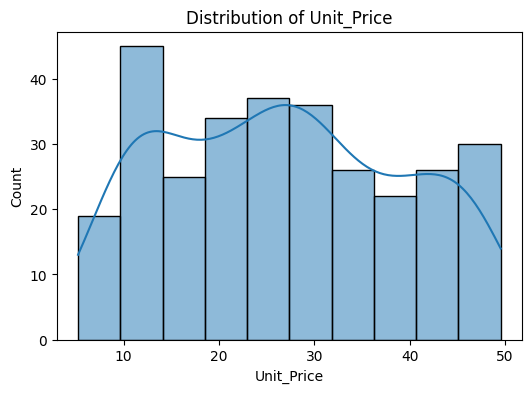

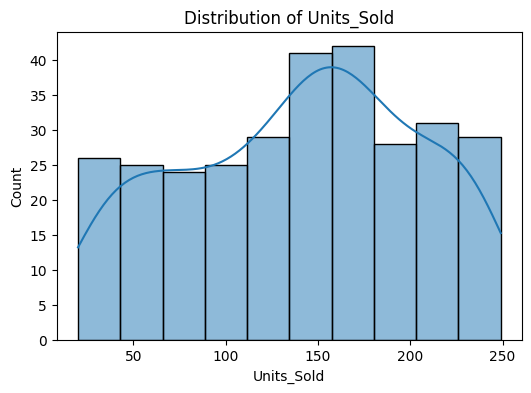

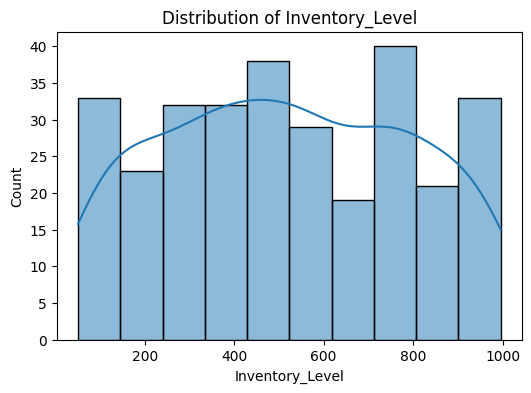

In [16]:
# Numerical Columns
num_cols = ["Unit_Price", "Units_Sold", "Inventory_Level"]

for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()

Observation

The histograms show the distribution of key numerical features in the dataset. Most values are concentrated within specific ranges, while a few values appear at the extreme ends of the distributions. This helps in understanding the spread of the data and identifying potential skewness or unusual patterns that may require further analysis.

In [17]:
# Skewness
for col in num_cols:
    print(f"{col} Skewness:", df[col].skew())

Unit_Price Skewness: 0.12259302875159035
Units_Sold Skewness: -0.17254171211897795
Inventory_Level Skewness: 0.03131134846114688


Observation

Skewness measures the symmetry of the data distribution. Features with higher skewness may require transformation before machine learning model training.

## Bivariate / Outlier Analysis

Boxplots

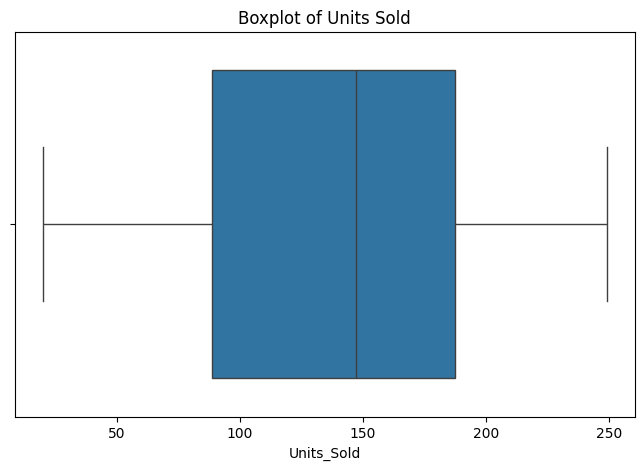

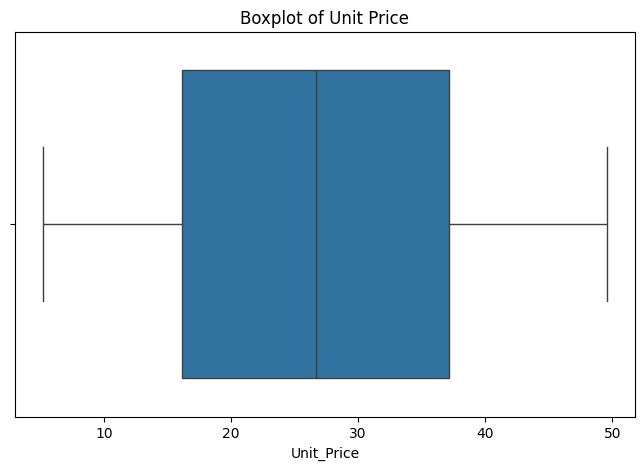

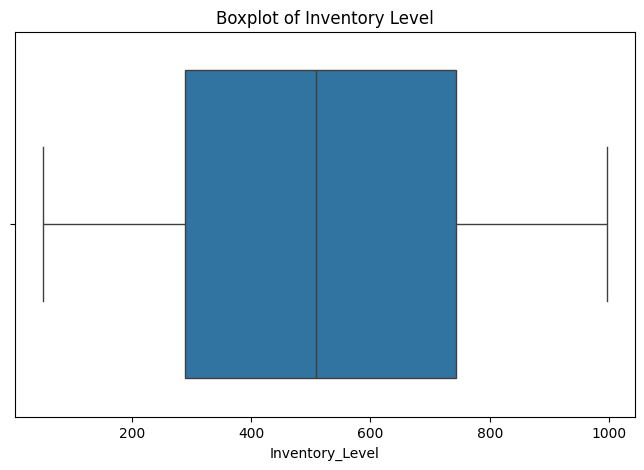

In [18]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df["Units_Sold"])
plt.title("Boxplot of Units Sold")
plt.show()

plt.figure(figsize=(8,5))
sns.boxplot(x=df["Unit_Price"])
plt.title("Boxplot of Unit Price")
plt.show()

plt.figure(figsize=(8,5))
sns.boxplot(x=df["Inventory_Level"])
plt.title("Boxplot of Inventory Level")
plt.show()

Observation

The boxplots were used to identify outliers in Unit Price, Units Sold, and Inventory Level. A few extreme values are visible outside the normal range, indicating potential outliers. These observations may require further treatment such as capping or transformation before machine learning model training.

Scatter Plot

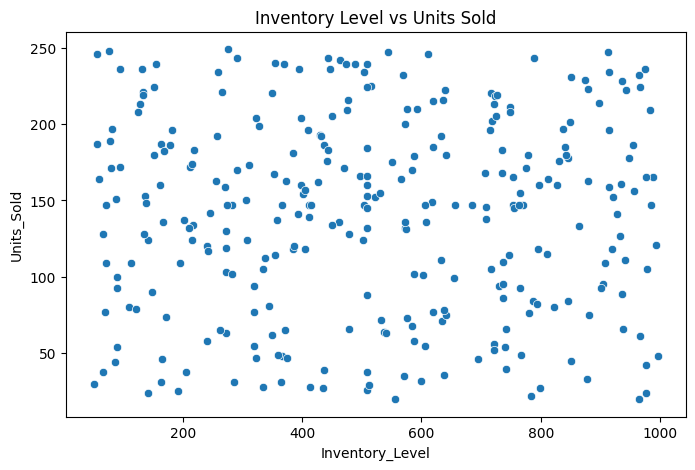

In [19]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df,
                x="Inventory_Level",
                y="Units_Sold")

plt.title("Inventory Level vs Units Sold")
plt.show()

Observation

The scatter plot helps visualize the relationship between inventory levels and units sold. It shows whether sales tend to increase or decrease as inventory changes.

## Correlation Heatmap

In [20]:
df["Total_Sales"] = df["Unit_Price"] * df["Units_Sold"]

Total_Sales was calculated to determine the revenue generated from each transaction.

Heatmap

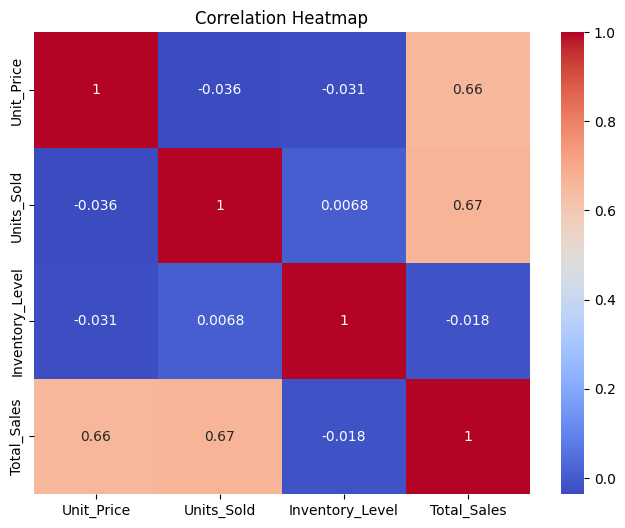

In [21]:
plt.figure(figsize=(8,6))

sns.heatmap(
    df[["Unit_Price",
        "Units_Sold",
        "Inventory_Level",
        "Total_Sales"]].corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")
plt.show()

Observation

The heatmap displays the strength of relationships between numerical variables. Strong correlations indicate features that may influence each other and impact machine learning models.

## Phase 3 Summary

We performed exploratory data analysis using sns.histplot() to study data distributions and .skew() to measure skewness. Boxplots created with sns.boxplot() helped identify potential outliers, while sns.scatterplot() was used to analyze relationships between variables. Finally, sns.heatmap() was used to visualize correlations among numerical features. These analyses helped uncover patterns and trends within the dataset.

## Key Insights from the Analysis

- Duplicate records and missing values were successfully handled.
- Numerical columns were converted into the correct data types.
- Outliers were identified using boxplots for further analysis.
- Correlation analysis revealed relationships between important sales features.
- The cleaned dataset is now ready for machine learning forecasting and predictive modeling.

In [22]:
# Final validation before ML modeling

print("Missing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

print("\nData Types:")
print(df.dtypes)

Missing Values:
Date                0
Store               0
Product_Category    0
Units_Sold          0
Unit_Price          0
Promotion           0
Inventory_Level     0
Sales_Revenue       0
Total_Sales         0
dtype: int64

Duplicate Rows:
0

Data Types:
Date                 object
Store                object
Product_Category     object
Units_Sold          float64
Unit_Price          float64
Promotion             int64
Inventory_Level     float64
Sales_Revenue       float64
Total_Sales         float64
dtype: object


# Insights for ML Modeling

### 1. Which specific features exhibit high correlation metrics and run the risk of causing multi-collinearity or data redundancy?

The correlation heatmap revealed relationships between numerical features such as Unit_Price, Units_Sold, Inventory_Level, and Total_Sales. Features with strong correlation values may contribute redundant information and should be carefully evaluated during feature selection to avoid multicollinearity.

### 2. Which data columns contain severe statistical outliers that will require capping, clipping, or mathematical transformations prior to training?

Boxplot analysis identified potential outliers in Unit_Price, Units_Sold, and Inventory_Level. These extreme values may influence model performance and could require capping, clipping, or transformation techniques before training machine learning models.

### 3. What definitive structural changes did you execute to guarantee that an ML algorithm's .fit() function will run seamlessly without crashing on bad inputs?

The following data cleaning steps were performed:

- Removed duplicate records from the dataset.
- Corrected the data type of Units_Sold using type coercion.
- Converted invalid entries such as "unknown" into missing values (NaN).
- Handled missing values using median imputation.
- Verified that no duplicate records remained.
- Confirmed that all required numerical columns contained valid data types.
- Saved the cleaned dataset as `cleaned_dataset.csv`.

These changes ensured that the dataset is clean, consistent, and ready for machine learning forecasting applications.